In [1]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn glob2 pyarrow matplotlib seaborn imbalanced-learn

In [1]:
import pandas as pd
import glob
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

# ==========================================
# LE THANH DAT (TASK 2.2)
# 1. TỔNG HỢP VÀ DỌN DẸP DỮ LIỆU 
# ==========================================

path = '../data/*.csv'
files = glob.glob(path)

# Nếu đã có file pkl rồi thì load luôn, không cần đọc lại 8 CSV
if os.path.exists('../models/cleaned_data.pkl'):
    print("Tìm thấy cleaned_data.pkl, đang load...")
    df = joblib.load('../models/cleaned_data.pkl')
    print("Load xong!")

elif not files:
    print("LỖI: Không tìm thấy file CSV nào trong thư mục data!")

else:
    # Gộp tất cả file thành 1 DataFrame lớn
    print(f"Đang gộp {len(files)} file dữ liệu...")
    df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    # 1. Dọn dẹp khoảng trắng tên cột
    df.columns = df.columns.str.strip()

    # Mapping từ tên cột thực tế (của bạn) sang tên cột yêu cầu (của Lab)
    column_mapping = {
        'Destination Port': 'Dst Port',
        'Total Fwd Packets': 'Tot Fwd Pkts',
        'Total Backward Packets': 'Tot Bwd Pkts',
        'Total Length of Fwd Packets': 'TotLen Fwd Pkts',
        'Total Length of Bwd Packets': 'TotLen Bwd Pkts',
        'Fwd Packet Length Mean': 'Fwd Pkt Len Mean',
        'Bwd Packet Length Mean': 'Bwd Pkt Len Mean',
        'Flow Bytes/s': 'Flow Byts/s',
        'Flow Packets/s': 'Flow Pkts/s',
        'Packet Length Mean': 'Pkt Len Mean',
        'Packet Length Std': 'Pkt Len Std',
        'FIN Flag Count': 'FIN Flag Cnt',
        'SYN Flag Count': 'SYN Flag Cnt',
        'RST Flag Count': 'RST Flag Cnt',
        'PSH Flag Count': 'PSH Flag Cnt',
        'ACK Flag Count': 'ACK Flag Cnt',
        'URG Flag Count': 'URG Flag Cnt'
    }

    df.rename(columns=column_mapping, inplace=True)
    print("Đã đồng bộ hóa tên cột theo yêu cầu Lab.")

    # 2. Loại bỏ dữ liệu trùng lặp trước (Giảm số hàng cần xử lý phía sau)
    print("Đang loại bỏ dữ liệu trùng lặp...")
    df.drop_duplicates(inplace=True)

    # 3. Xử lý giá trị vô hạn (inf)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 4. Điền các giá trị trống bằng trung vị (median)
    # Lưu ý: numeric_only=True là bắt buộc để tránh lỗi với cột Label (chữ)
    df.fillna(df.median(numeric_only=True), inplace=True)

    # 5. Loại bỏ các cột biến thiên bằng 0 (PHẢI GÁN LẠI BIẾN DF)
    print("Đang loại bỏ các cột zero-variance...")
    non_zero_var_cols = [col for col in df.columns if df[col].nunique() > 1]
    df = df[non_zero_var_cols] # <--- Cần dòng này để thực thi việc lọc

    # 6. Tối ưu RAM
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')

    # Lưu lại
    joblib.dump(df, '../models/cleaned_data.pkl')
    print(f"Hoàn thành! Số lượng cột còn lại: {df.shape[1]}")

Đang gộp 8 file dữ liệu...
Đã đồng bộ hóa tên cột theo yêu cầu Lab.
Đang loại bỏ dữ liệu trùng lặp...
Đang loại bỏ các cột zero-variance...
Hoàn thành! Số lượng cột còn lại: 71


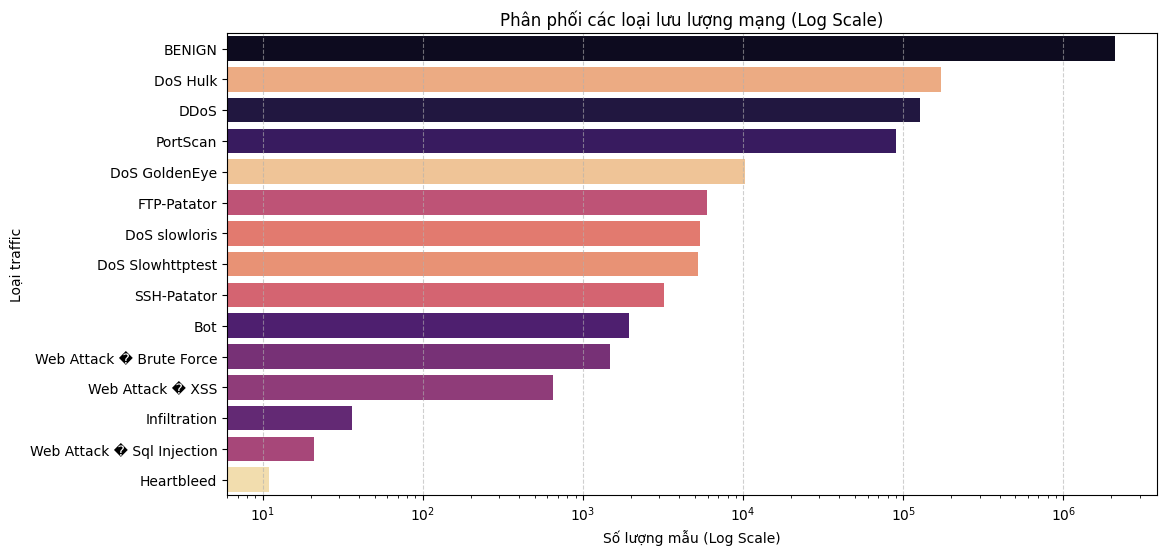

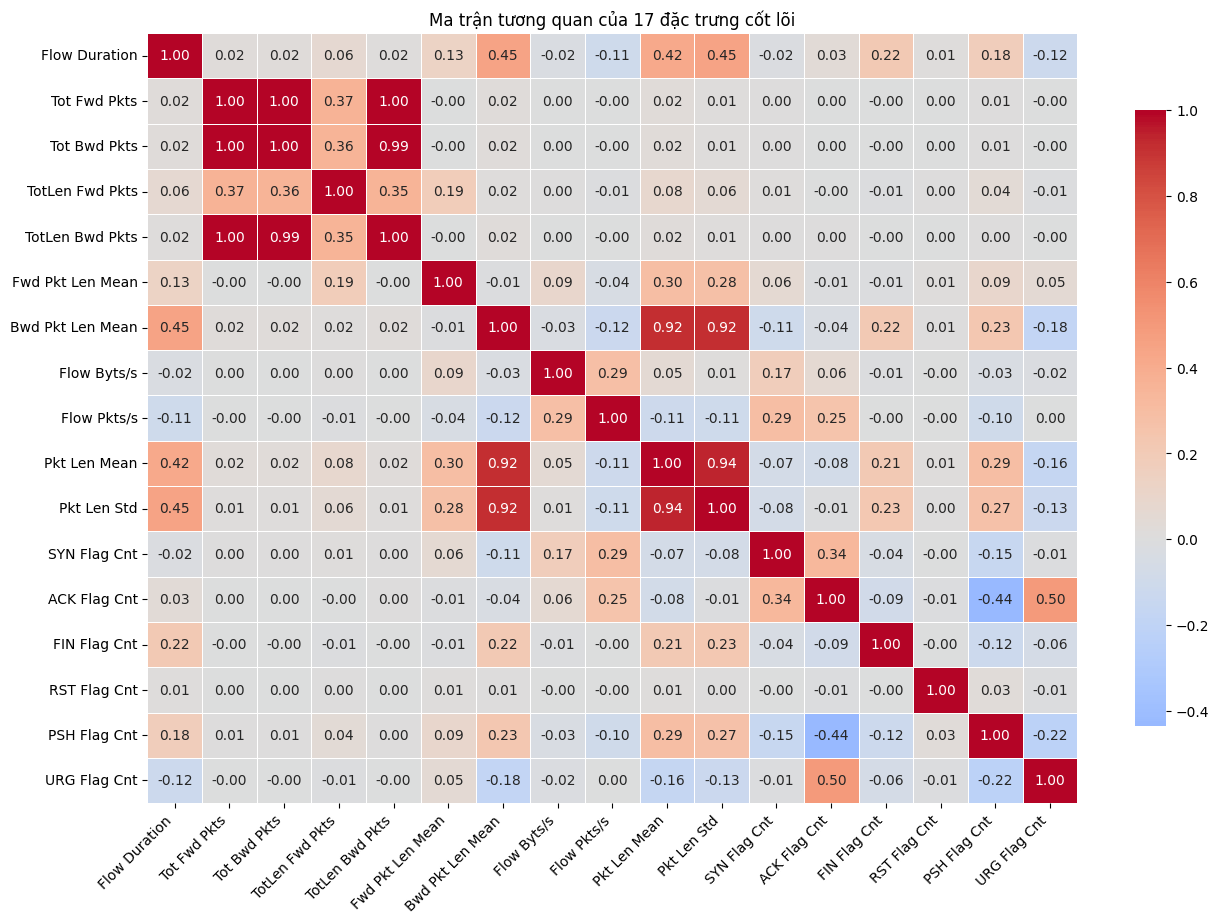

In [2]:
# ==============================================================================
# TASK 2.2: EXPLORATORY DATA ANALYSIS (EDA)
# Mục tiêu: Thấu hiểu phân phối nhãn và mối tương quan giữa các đặc trưng cốt lõi.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PHÂN PHỐI NHÃN (TARGET DISTRIBUTION)
# Khắc phục FutureWarning bằng cách gán x/y và hue rõ ràng
plt.figure(figsize=(12, 6))
sns.countplot(
    y='Label', 
    data=df, 
    hue='Label',
    palette='magma', 
    order=df['Label'].value_counts().index,
    legend=False
)
plt.xscale('log') # Hiển thị rõ các lớp thiểu số như Heartbleed, Infiltration
plt.title('Phân phối các loại lưu lượng mạng (Log Scale)')
plt.xlabel('Số lượng mẫu (Log Scale)')
plt.ylabel('Loại traffic')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 2. MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP)
# Danh sách 18 đặc trưng cốt lõi theo yêu cầu 2.4
selected_features = [
    'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean',
    'Flow Byts/s', 'Flow Pkts/s', 'Pkt Len Mean', 'Pkt Len Std', 
    'SYN Flag Cnt', 'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt', 
    'PSH Flag Cnt', 'URG Flag Cnt'
]

# Tự động tìm tên cột thực tế (xử lý trường hợp dư khoảng trắng đầu/cuối)
actual_columns = {col.strip(): col for col in df.columns}
existing_features = [actual_columns[f] for f in selected_features if f in actual_columns]

if len(existing_features) > 1:
    plt.figure(figsize=(15, 10))
    # Tính toán ma trận tương quan
    corr = df[existing_features].corr()
    
    # Vẽ Heatmap với cấu hình chuẩn
    sns.heatmap(
        corr, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        center=0, 
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )
    plt.title(f'Ma trận tương quan của {len(existing_features)} đặc trưng cốt lõi')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print(f"CẢNH BÁO: Chỉ tìm thấy {len(existing_features)} cột. Kiểm tra lại df.columns!")
    print("Cột thực tế đang có:", df.columns.tolist()[:5], "...")

In [3]:
# ==========================================
# NGUYEN QUOC DAT 
# 2.3 XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU
# ==========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import joblib

# Load df nếu chưa có
if 'df' not in dir():
    df = joblib.load('../models/cleaned_data.pkl')

# Encode Label
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
print("Các nhãn:", list(le.classes_))

# Tách X (78 features), y
X = df.drop('Label', axis=1)
y = df['Label']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Xem phân phối trước
print("\nTrước khi balance:")
print(pd.Series(y_train).value_counts())

# SMOTE + RandomUnderSampler
majority_count = pd.Series(y_train).value_counts().max()
threshold = int(majority_count * 0.1)

sampling_strategy_smote = {
    cls: max(count, threshold)
    for cls, count in pd.Series(y_train).value_counts().items()
    if count < majority_count
}

pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=sampling_strategy_smote, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy='majority', random_state=42))
])

X_train, y_train = pipeline.fit_resample(X_train, y_train)

print("\nSau khi balance:")
print(pd.Series(y_train).value_counts())

# Lưu lại
joblib.dump((X_train, X_test, y_train, y_test), '../models/balanced_data.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
print("\nĐã lưu balanced_data.pkl!")

Các nhãn: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

Trước khi balance:
Label
0     1677187
4      138279
2      102413
10      72655
3        8229
7        4746
6        4308
5        4182
11       2575
1        1562
12       1176
14        522
9          29
13         17
8           9
Name: count, dtype: int64

Sau khi balance:
Label
0     167718
1     167718
2     167718
3     167718
4     167718
5     167718
6     167718
7     167718
8     167718
9     167718
10    167718
11    167718
12    167718
13    167718
14    167718
Name: count, dtype: int64

Đã lưu balanced_data.pkl!


In [10]:
print(X.columns.tolist())

['Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Pkt Len Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Pkt Len Mean', 'Bwd Packet Length Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Pkt Len Mean', 'Pkt Len Std', 'Packet Length Variance', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflo

In [4]:
print(X_train.shape)

(2515770, 70)


In [5]:
# ==========================================
# LE KIM BUU (TASK 2.4)
# 2.4 FEATURE SELECTION
# ==========================================

# lưu lại tên cột gốc
feature_names = X.columns.tolist()

# convert numpy → DataFrame
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

# chọn feature đúng theo dataset 
selected_features = [
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean',
    'Flow Byts/s',
    'Flow Pkts/s',
    'Pkt Len Mean',
    'Pkt Len Std',
    'SYN Flag Cnt',
    'ACK Flag Cnt',
    'FIN Flag Cnt',
    'RST Flag Cnt',
    'PSH Flag Cnt',
    'URG Flag Cnt'
]

# check lỗi trước khi select
missing = set(selected_features) - set(X_train.columns)
if missing:
    print(f"Thiếu features: {missing}")
else:
    print("Tất cả features hợp lệ!")

# select feature
X_train = X_train[selected_features].values
X_test = X_test[selected_features].values

print("\nSau khi feature selection:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

joblib.dump((X_train, X_test, y_train, y_test), '../models/processed_data.pkl')
print("Đã lưu processed_data.pkl!")

Tất cả features hợp lệ!

Sau khi feature selection:
X_train: (2515770, 17)
X_test: (504473, 17)
Đã lưu processed_data.pkl!


In [ ]:
# ==========================================
# LE THANH DAT (TASK 2.5)
# 2. HUẤN LUYỆN MÔ HÌNH BASELINE 
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

X_train, X_test, y_train, y_test = joblib.load('../models/processed_data.pkl')
le = joblib.load('../models/label_encoder.pkl')

# Huấn luyện mô hình Logistic Regression
# Tăng max_iter để đảm bảo mô hình hội tụ tốt hơn
print("Đang huấn luyện mô hình Logistic Regression (có thể mất vài phút)...")
model = LogisticRegression(max_iter=500, solver='lbfgs')
model.fit(X_train, y_train)

# ==========================================
# 3. ĐÁNH GIÁ VÀ LƯU TRỮ (OUTPUT)
# ==========================================

# Tính toán độ chính xác tổng quát
accuracy = model.score(X_test, y_test)
print(f"\n--- KẾT QUẢ ---")
print(f"Độ chính xác tổng thể: {accuracy:.4f}")

# Dự đoán và in báo cáo chi tiết (Precision, Recall, F1-score)
y_pred = model.predict(X_test)
print("\nBáo cáo chi tiết cho từng loại tấn công:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

# Tạo thư mục và lưu trữ model đã học
joblib.dump(model, '../models/logistic_regression.pkl')

print("\nĐã lưu 'logistic_regression.pkl' vào thư mục models.")

Đang huấn luyện mô hình Logistic Regression (có thể mất vài phút)...


Đang train SVM...


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



--- KẾT QUẢ SVM ---
Độ chính xác: 0.5728
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.51      0.67    419297
                       Bot       0.01      0.67      0.02       391
                      DDoS       0.42      0.98      0.58     25603
             DoS GoldenEye       0.07      0.66      0.12      2057
                  DoS Hulk       0.80      0.86      0.83     34570
          DoS Slowhttptest       0.06      0.80      0.11      1046
             DoS slowloris       0.05      0.56      0.08      1077
               FTP-Patator       0.03      0.31      0.05      1187
                Heartbleed       0.25      1.00      0.40         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.64      0.99      0.78     18164
               SSH-Patator       0.03      0.92      0.06       644
  Web Attack � Brute Force       0.00      0.05      0.01       294
Web A

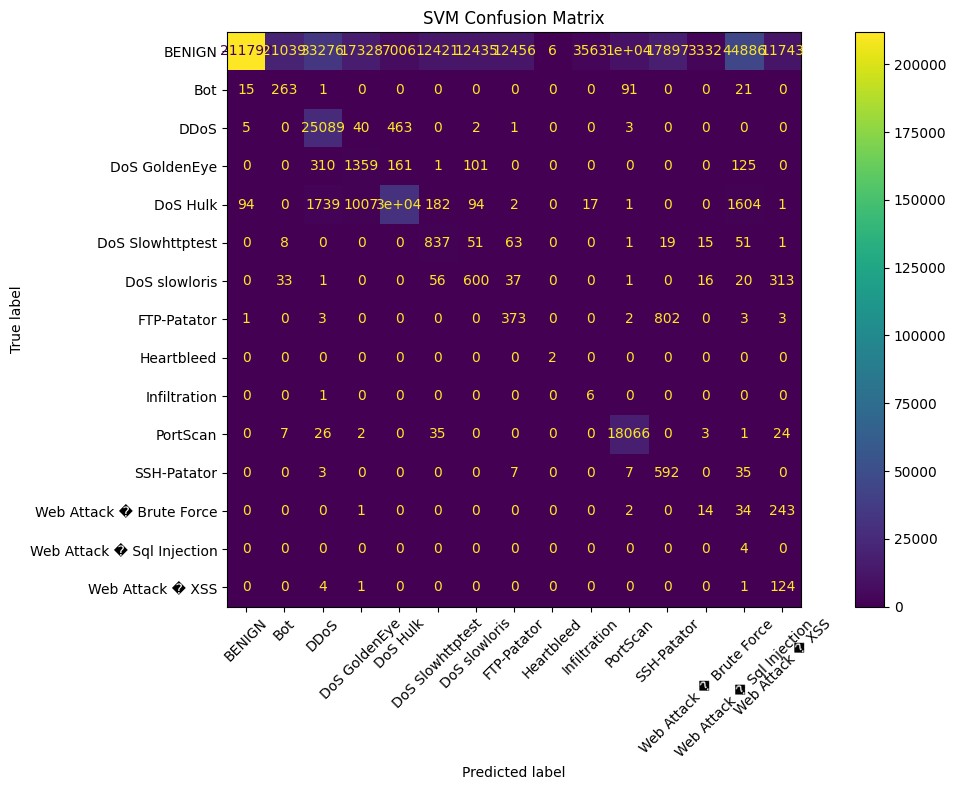

Đã lưu svm_model.pkl!


In [9]:
# ==========================================
# NGUYEN QUOC DAT (TASK 2.5)
# SUPPORT VECTOR MACHINE (SVM)
# ==========================================

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Load data đã xử lý từ 2.4
X_train, X_test, y_train, y_test = joblib.load('../models/processed_data.pkl')
le = joblib.load('../models/label_encoder.pkl')

# Train SVM
# Dùng LinearSVC thay SVC vì nhanh hơn với dataset lớn
print("Đang train SVM...")
model_svm = LinearSVC(max_iter=500, tol=1e-3, random_state=42)
model_svm.fit(X_train, y_train)

# Đánh giá
y_pred = model_svm.predict(X_test)
accuracy = model_svm.score(X_test, y_test)

print(f"\n--- KẾT QUẢ SVM ---")
print(f"Độ chính xác: {accuracy:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# Lưu model
joblib.dump(model_svm, '../models/svm_model.pkl')
print("Đã lưu svm_model.pkl!")

Đang train KNN (có thể mất thời gian ở khâu dự đoán do đặc thù của KNN)...

--- KẾT QUẢ KNN ---
Độ chính xác: 0.9804
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99    419297
                       Bot       0.26      0.62      0.36       391
                      DDoS       0.99      1.00      0.99     25603
             DoS GoldenEye       0.75      0.99      0.85      2057
                  DoS Hulk       0.97      0.99      0.98     34570
          DoS Slowhttptest       0.75      0.99      0.85      1046
             DoS slowloris       0.83      0.99      0.91      1077
               FTP-Patator       0.95      0.99      0.97      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.03      0.71      0.06         7
                  PortScan       0.99      0.94      0.96     18164
               SSH-Patator       0.61      0.94      0.74       64

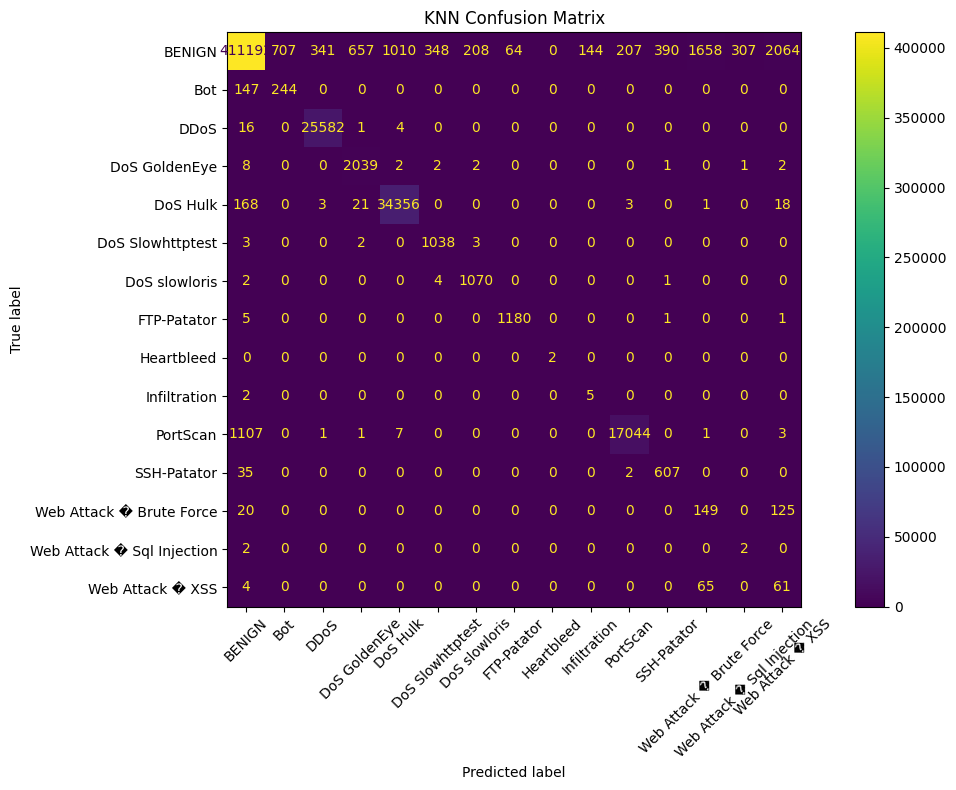

Đã lưu knn_model.pkl!


In [6]:
# ==========================================
# NGUYỄN TRẦN MẠNH DŨNG
# K-NEAREST NEIGHBORS (KNN)
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Load data đã xử lý từ 2.4 (Đã bao gồm Scale ở 2.3 và Feature Selection ở 2.4)
X_train, X_test, y_train, y_test = joblib.load('../models/processed_data.pkl')
le = joblib.load('../models/label_encoder.pkl')

# Train KNN
# Thêm n_jobs=-1 để sử dụng toàn bộ nhân CPU giúp KNN chạy/dự đoán nhanh hơn
print("Đang train KNN (có thể mất thời gian ở khâu dự đoán do đặc thù của KNN)...")
model_knn = KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)
model_knn.fit(X_train, y_train)

# Đánh giá
y_pred = model_knn.predict(X_test)
accuracy = model_knn.score(X_test, y_test)

print(f"\n--- KẾT QUẢ KNN ---")
print(f"Độ chính xác: {accuracy:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

# Lưu model
joblib.dump(model_knn, '../models/knn_model.pkl')
print("Đã lưu knn_model.pkl!")

In [ ]:
# ==========================================
# # NGUYEN THAI BINH #random_forest_model
# ==========================================

import pandas as pd
import glob
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# ===== LOAD DATA =====
df = pd.concat([pd.read_csv(f) for f in glob.glob('../data/*.csv')], ignore_index=True)

df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

df = df.sample(n=30000, random_state=42)

# ===== PREPARE =====
X = df.drop('Label', axis=1)
y = df['Label']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ===== RANDOM FOREST =====
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# ===== SAVE =====
joblib.dump(model, '../models/random_forest_model.pkl')

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5001
           1       0.00      0.00      0.00         4
           2       0.99      1.00      0.99       278
           3       1.00      0.86      0.93        22
           4       1.00      0.98      0.99       414
           5       0.90      0.90      0.90        10
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        13
           8       1.00      0.98      0.99       225
           9       1.00      0.90      0.95        10
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2

    accuracy                           0.99      6000
   macro avg       0.74      0.72      0.73      6000
weighted avg       0.99      0.99      0.99      6000



c:\Users\tamdz\Downloads\Network-Intrusion-Detection-ML-main\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tamdz\Downloads\Network-Intrusion-Detection-ML-main\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tamdz\Downloads\Network-Intrusion-Detection-ML-main\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

['../models/random_forest_model.pkl']

In [ ]:
# ==========================================
# 2.6 REAL-TIME DETECTION Nguyen Thai Binh
# ==========================================

import joblib
import pandas as pd

# ===== LOAD =====
model = joblib.load('../models/random_forest_model.pkl') 
le = joblib.load('../models/label_encoder.pkl')
feature_columns = joblib.load('../models/feature_columns.pkl')

# ===== FUNCTION =====
def detect_realtime(sample_input):
    # tạo dataframe từ input
    sample_df = pd.DataFrame([sample_input])

    # đảm bảo đúng thứ tự feature
    sample_df = sample_df.reindex(columns=feature_columns, fill_value=0)

    # predict
    pred = model.predict(sample_df)[0]
    label = le.inverse_transform([pred])[0]

    # alert
    if label != "BENIGN":
        print(f"[ALERT] Suspicious traffic detected: {label}. Destination Port: {sample_input.get('Dst Port', 'Unknown')}.")
    else:
        print("[INFO] Normal traffic (BENIGN)")

# ===== TEST =====
# giả lập 1 flow từ dataset
sample = df.drop('Label', axis=1).iloc[0].to_dict()

detect_realtime(sample)

[INFO] Normal traffic (BENIGN)
